In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import os
import requests
import zipfile
from tqdm import tqdm # Optional: adds a nice progress bar

# Configuration
classes_to_download = ["walking", "boxing", "handclapping"]
base_url = "http://www.csc.kth.se/cvap/actions/"
output_dir = "./kth_videos/"

os.makedirs(output_dir, exist_ok=True)

def download_and_extract(action):
    zip_filename = f"{action}.zip"
    url = f"{base_url}{zip_filename}"
    zip_path = os.path.join(output_dir, zip_filename)

    print(f"--- Processing '{action}' ---")
    
    # Downloading using requests (works on Windows/Mac/Linux)
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    else:
        print(f"Failed to download {action}. Status code: {response.status_code}")
        return

    # Extracting using zipfile (built-in Python library)
    print(f"Extracting {zip_filename}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    # Clean up the zip file
    os.remove(zip_path)
    print(f"Done with {action}!\n")

if __name__ == "__main__":
    print("Starting downloads...")
    for action in classes_to_download:
        download_and_extract(action)
    print(f"All selected classes are ready in: {os.path.abspath(output_dir)}")

Starting downloads...
--- Processing 'walking' ---
Extracting walking.zip...
Done with walking!

--- Processing 'boxing' ---
Extracting boxing.zip...
Done with boxing!

--- Processing 'handclapping' ---
Extracting handclapping.zip...
Done with handclapping!

All selected classes are ready in: c:\Users\Ayushman\VL-JEPA-base-CCTV\kth_videos


In [5]:
import cv2
import numpy as np
import pandas as pd
import os

def process_kth_dataset(video_dir=r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_videos", output_csv="kth_cctv_features.csv"):
    print(f"Scanning directory {video_dir} for KTH videos...")

    if not os.path.exists(video_dir):
        print(f"Error: Directory {video_dir} not found. Please ensure your videos are extracted here.")
        return 0

    video_files = [f for f in os.listdir(video_dir) if f.endswith('.avi')]
    print(f"Found {len(video_files)} video files. Starting feature extraction...")

    dataset_records = []
    label_to_id = {}
    current_class_id = 0

    for filename in video_files:

        action_label = filename.split('_')[1]

        if action_label not in label_to_id:
            label_to_id[action_label] = current_class_id
            current_class_id += 1

        target_class_id = label_to_id[action_label]
        video_path = os.path.join(video_dir, filename)
        cap = cv2.VideoCapture(video_path)

        # Sample 5 frames per video
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames < 20:
            cap.release()
            continue

        frames_to_sample = np.linspace(10, total_frames - 10, 5, dtype=int)

        for frame_idx in frames_to_sample:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret: continue

            # Apply Simulated CCTV Occlusion Mask
            mask_x1, mask_x2 = 60, 100
            mask_y1, mask_y2 = 40, 80
            cv2.rectangle(frame, (mask_x1, mask_y1), (mask_x2, mask_y2), (0, 0, 0), -1)

            # Convert to HSV and extract 256-bin histogram
            hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            hist = cv2.calcHist([hsv_frame], [0, 1], None, [16, 16], [0, 180, 0, 256])
            cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

            features = hist.flatten().tolist()

            dataset_records.append({
                "video_file": filename,
                "target_class": target_class_id,
                "hsv_features": features
            })

        cap.release()

    # Save to CSV
    df = pd.DataFrame(dataset_records)
    df.to_csv(output_csv, index=False)

    print("\n--- Extraction Complete! ---")
    print(f"Total frames processed: {len(df)}")
    print(f"Classes found: {label_to_id}")
    print(f"Saved dataset to {output_csv}")

    return len(label_to_id)

num_found_classes = process_kth_dataset()

Scanning directory C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_videos for KTH videos...
Found 299 video files. Starting feature extraction...

--- Extraction Complete! ---
Total frames processed: 1494
Classes found: {'boxing': 0, 'handclapping': 1, 'walking': 2}
Saved dataset to kth_cctv_features.csv


In [26]:
# import numpy as np
# import pandas as pd
# import ast
# import matplotlib.pyplot as plt

# class FinalNumPyJEPA:
#     def __init__(self, input_dim, target_classes, embed_dim=64, lr=0.01):
#         self.lr = lr

#         self.W_v = np.random.randn(embed_dim, input_dim) * np.sqrt(2. / input_dim)
#         self.b_v = np.zeros((embed_dim, 1))

#         self.W_y = np.random.randn(embed_dim, target_classes) * np.sqrt(2. / target_classes)
#         self.b_y = np.zeros((embed_dim, 1))

#         self.W_p = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
#         self.b_p = np.zeros((embed_dim, 1))

#     def relu(self, Z): return np.maximum(0, Z)
#     def relu_deriv(self, Z): return Z > 0

#     def forward(self, X_v, Y):
#         # Encoders
#         Z_v = np.dot(self.W_v, X_v) + self.b_v
#         self.S_v = self.relu(Z_v)
#         self.S_y = np.dot(self.W_y, Y) + self.b_y

#         # Predictor
#         self.S_y_hat = np.dot(self.W_p, self.S_v) + self.b_p

#         # JEPA Embedding Loss
#         loss = 0.5 * np.sum((self.S_y_hat - self.S_y)**2)
#         return loss, Z_v

#     def backward(self, X_v, Y, Z_v):
#         d_S_y_hat = self.S_y_hat - self.S_y

#         # Predictor Gradients
#         d_W_p = np.dot(d_S_y_hat, self.S_v.T)
#         d_b_p = d_S_y_hat

#         # Visual Encoder Gradients
#         d_S_v = np.dot(self.W_p.T, d_S_y_hat)
#         d_Z_v = d_S_v * self.relu_deriv(Z_v)
#         d_W_v = np.dot(d_Z_v, X_v.T)
#         d_b_v = d_Z_v

#         # Target Encoder Gradients
#         d_S_y = -d_S_y_hat
#         d_W_y = np.dot(d_S_y, Y.T)
#         d_b_y = d_S_y

#         # Weight Updates
#         self.W_p -= self.lr * d_W_p; self.b_p -= self.lr * d_b_p
#         self.W_v -= self.lr * d_W_v; self.b_v -= self.lr * d_b_v
#         self.W_y -= self.lr * d_W_y; self.b_y -= self.lr * d_b_y

# def run_training_and_plot(csv_path=r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_motion_features2.csv", num_classes=3, epochs=40):
#     print(f"Loading dataset from {csv_path}...")
#     try:
#         df = pd.read_csv(csv_path)
#     except FileNotFoundError:
#         print("Error: CSV not found. Did you run the extraction cell first?")
#         return

#     df['hsv_features'] = df['hsv_features'].apply(ast.literal_eval)


#     model = FinalNumPyJEPA(input_dim=256, target_classes=num_classes, embed_dim=64, lr=0.005)
#     loss_history = []

#     print("Starting Training Simulation...")
#     for epoch in range(epochs):
#         df_shuffled = df.sample(frac=1).reset_index(drop=True)
#         epoch_loss = 0

#         for index, row in df_shuffled.iterrows():
#             X_v = np.array(row['hsv_features']).reshape(256, 1)
#             Y = np.zeros((num_classes, 1))
#             Y[int(row['target_class']), 0] = 1.0

#             loss, Z_v = model.forward(X_v, Y)
#             model.backward(X_v, Y, Z_v)
#             epoch_loss += loss

#         avg_loss = epoch_loss / len(df)
#         loss_history.append(avg_loss)
#         if (epoch+1) % 5 == 0 or epoch == 0:
#             print(f"Epoch {epoch+1}/{epochs} | Average JEPA Latent Loss: {avg_loss:.4f}")
   


#     plt.figure(figsize=(9, 5))
#     plt.plot(loss_history, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
#     plt.title('VL-JEPA: NumPy Embedding-Space Training Loss', fontsize=14, fontweight='bold')
#     plt.xlabel('Training Epochs', fontsize=12)
#     plt.ylabel('L2 Latent Distance', fontsize=12)
#     plt.grid(True, linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     plt.show()


# try:
#     run_training_and_plot(num_classes=num_found_classes, epochs=40)
# except NameError:

#     print("Please manually enter the number of classes found:")
#     manual_classes = int(input("> "))
#     run_training_and_plot(num_classes=manual_classes, epochs=40)


Loading Motion Features from C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_motion_features2.csv...
Starting Training on 299 motion samples...
Epoch 1/100 | Avg Loss: 15.461656
Epoch 10/100 | Avg Loss: 0.395781
Epoch 20/100 | Avg Loss: 0.023689
Epoch 30/100 | Avg Loss: 0.011844
Epoch 40/100 | Avg Loss: 0.009379
Epoch 50/100 | Avg Loss: 0.007969
Epoch 60/100 | Avg Loss: 0.006963
Epoch 70/100 | Avg Loss: 0.006230
Epoch 80/100 | Avg Loss: 0.005640
Epoch 90/100 | Avg Loss: 0.005146
Epoch 100/100 | Avg Loss: 0.004736

--- Training Results ---
Final Accuracy: 52.51%


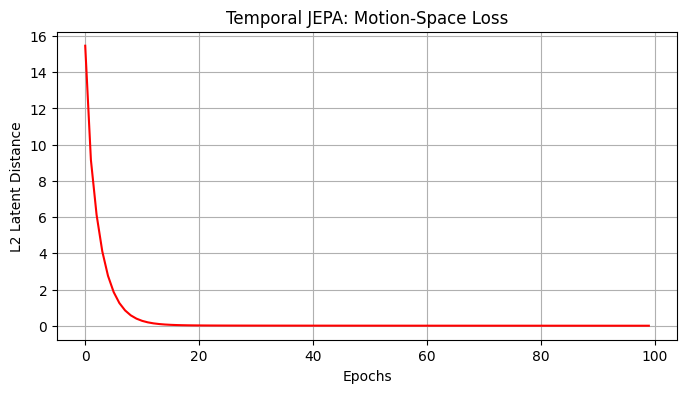

In [24]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt

# --- 1. The JEPA Class (Remains the same as your stable version) ---
class FinalNumPyJEPA:
    def __init__(self, input_dim, target_classes, embed_dim=64, lr=0.01):
        self.lr = lr
        self.W_v = np.random.randn(embed_dim, input_dim) * np.sqrt(2. / input_dim)
        self.b_v = np.zeros((embed_dim, 1))
        self.W_y = np.random.randn(embed_dim, target_classes) * np.sqrt(2. / target_classes)
        self.b_y = np.zeros((embed_dim, 1))
        self.W_p = np.random.randn(embed_dim, embed_dim) * np.sqrt(2. / embed_dim)
        self.b_p = np.zeros((embed_dim, 1))

    def relu(self, Z): return np.maximum(0, Z)
    def relu_deriv(self, Z): return Z > 0

    def forward(self, X_v, Y):
        Z_v = np.dot(self.W_v, X_v) + self.b_v
        self.S_v = self.relu(Z_v)
        self.S_y = np.dot(self.W_y, Y) + self.b_y
        self.S_y_hat = np.dot(self.W_p, self.S_v) + self.b_p
        loss = 0.5 * np.sum((self.S_y_hat - self.S_y)**2)
        return loss, Z_v

    def backward(self, X_v, Y, Z_v):
        d_S_y_hat = self.S_y_hat - self.S_y
        d_W_p = np.dot(d_S_y_hat, self.S_v.T)
        d_b_p = d_S_y_hat
        d_S_v = np.dot(self.W_p.T, d_S_y_hat)
        d_Z_v = d_S_v * self.relu_deriv(Z_v)
        d_W_v = np.dot(d_Z_v, X_v.T)
        d_b_v = d_Z_v
        d_S_y = -d_S_y_hat
        d_W_y = np.dot(d_S_y, Y.T)
        d_b_y = d_S_y
        self.W_p -= self.lr * d_W_p; self.b_p -= self.lr * d_b_p
        self.W_v -= self.lr * d_W_v; self.b_v -= self.lr * d_b_v
        self.W_y -= self.lr * d_W_y; self.b_y -= self.lr * d_b_y

# --- 2. Inference Helper ---
def predict(model, X_v, num_classes):
    Z_v = np.dot(model.W_v, X_v) + model.b_v
    S_v = model.relu(Z_v)
    S_y_hat = np.dot(model.W_p, S_v) + model.b_p
    
    distances = []
    for i in range(num_classes):
        Y_t = np.zeros((num_classes, 1))
        Y_t[i, 0] = 1.0
        S_y_target = np.dot(model.W_y, Y_t) + model.b_y
        distances.append(np.linalg.norm(S_y_hat - S_y_target))
    return np.argmin(distances)

# --- 3. Training Logic ---
def run_training_and_plot(csv_path, num_classes=3, epochs=50):
    print(f"Loading Motion Features from {csv_path}...")
    try:
        # Note: Updated to 'features' column name from the optical flow extraction
        df = pd.read_csv(csv_path)
        feature_col = 'features' if 'features' in df.columns else 'hsv_features'
        df[feature_col] = df[feature_col].apply(ast.literal_eval)
    except Exception as e:
        print(f"Error: {e}")
        return

    # Initialize Model
    model = FinalNumPyJEPA(input_dim=256, target_classes=num_classes, embed_dim=64, lr=0.002)
    loss_history = []

    print(f"Starting Training on {len(df)} motion samples...")
    for epoch in range(epochs):
        df_shuffled = df.sample(frac=1).reset_index(drop=True)
        epoch_loss = 0

        for _, row in df_shuffled.iterrows():
            X_v = np.array(row[feature_col]).reshape(256, 1)
            Y = np.zeros((num_classes, 1))
            Y[int(row['target_class']), 0] = 1.0

            loss, Z_v = model.forward(X_v, Y)
            model.backward(X_v, Y, Z_v)
            epoch_loss += loss

        avg_loss = epoch_loss / len(df)
        loss_history.append(avg_loss)
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.6f}")

    # --- Evaluation Phase ---
    correct = 0
    for _, row in df.iterrows():
        X_v = np.array(row[feature_col]).reshape(256, 1)
        pred = predict(model, X_v, num_classes)
        if pred == int(row['target_class']):
            correct += 1
    
    print(f"\n--- Training Results ---")
    print(f"Final Accuracy: {(correct/len(df))*100:.2f}%")

    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, color='red')
    plt.title('Temporal JEPA: Motion-Space Loss')
    plt.xlabel('Epochs')
    plt.ylabel('L2 Latent Distance')
    plt.grid(True)
    plt.show()
    
    return model

# --- 4. Execution ---
csv_file = r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_motion_features2.csv"
# You can set num_classes to 3 since we are doing walking, boxing, handclapping
trained_model = run_training_and_plot(csv_file, num_classes=3, epochs=100)

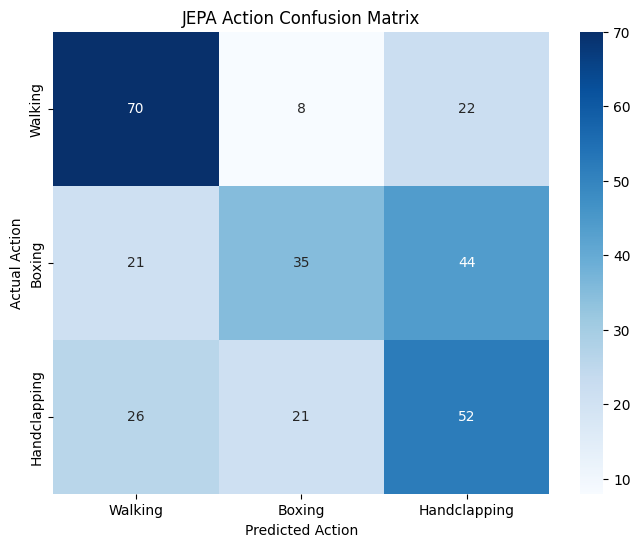


Detailed Performance Report:
              precision    recall  f1-score   support

     Walking       0.60      0.70      0.65       100
      Boxing       0.55      0.35      0.43       100
Handclapping       0.44      0.53      0.48        99

    accuracy                           0.53       299
   macro avg       0.53      0.53      0.52       299
weighted avg       0.53      0.53      0.52       299



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrix(model, df, num_classes, label_names, feature_col='features'):
    y_true = []
    y_pred = []
    
    for _, row in df.iterrows():
        X_v = np.array(row[feature_col]).reshape(256, 1)
        true_label = int(row['target_class'])
        
        pred_label = predict(model, X_v, num_classes)
        
        y_true.append(true_label)
        y_pred.append(pred_label)
    
    # Generate Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names)
    plt.title('JEPA Action Confusion Matrix')
    plt.ylabel('Actual Action')
    plt.xlabel('Predicted Action')
    plt.show()

    print("\nDetailed Performance Report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

# Usage (Assuming your labels are in this order):
labels = ["Walking", "Boxing", "Handclapping"]
plot_confusion_matrix(trained_model, df, 3, labels)

In [8]:
def test_model(model, X_v, num_classes):
    """
    Predicts the class by finding the minimum distance in latent space.
    """
    # 1. Forward pass through Visual Encoder
    Z_v = np.dot(model.W_v, X_v) + model.b_v
    S_v = model.relu(Z_v)
    
    # 2. Predict the target latent representation
    S_y_hat = np.dot(model.W_p, S_v) + model.b_p
    
    # 3. Compare S_y_hat to all possible Class Embeddings
    distances = []
    for i in range(num_classes):
        # Create a dummy one-hot vector for each class
        Y_test = np.zeros((num_classes, 1))
        Y_test[i, 0] = 1.0
        
        # Get the "ideal" latent embedding for this class
        S_y_ideal = np.dot(model.W_y, Y_test) + model.b_y
        
        # Calculate L2 distance (Euclidean)
        dist = np.linalg.norm(S_y_hat - S_y_ideal)
        distances.append(dist)
    
    # The predicted class is the one with the smallest distance
    return np.argmin(distances), distances

In [9]:
def evaluate_accuracy(model, csv_path, num_classes):
    df = pd.read_csv(csv_path)
    df['hsv_features'] = df['hsv_features'].apply(ast.literal_eval)
    
    correct = 0
    total = len(df)
    
    print(f"\n--- Evaluating on {total} frames ---")
    
    for _, row in df.iterrows():
        X_v = np.array(row['hsv_features']).reshape(256, 1)
        actual_class = int(row['target_class'])
        
        predicted_class, _ = test_model(model, X_v, num_classes)
        
        if predicted_class == actual_class:
            correct += 1
            
    accuracy = (correct / total) * 100
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{total})")

# Run evaluation
num_classes = num_found_classes
model = FinalNumPyJEPA(input_dim=256, target_classes=num_classes, embed_dim=64, lr=0.005)
evaluate_accuracy(model, "kth_cctv_features.csv", num_found_classes)


--- Evaluating on 1494 frames ---
Accuracy: 33.13% (495/1494)


In [23]:
import cv2
import numpy as np
import os
import pandas as pd

def get_motion_signature(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < 5:
        cap.release()
        return None

    # Jump to the middle of the video where action usually happens
    mid_frame = total_frames // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame)
    
    ret, frame1 = cap.read()
    ret, frame2 = cap.read()
    if not ret: 
        cap.release()
        return None

    # Convert to grayscale
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    curr_gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # Calculate Optical Flow (Farneback method)
    # This detects how every pixel moved from frame 1 to frame 2
    flow = cv2.calcOpticalFlowFarneback(prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    
    # Compute Magnitude (how much movement) and Angle (which direction)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # Create a 256-dimension Motion Histogram
    hist_mag = np.histogram(mag, bins=128, range=(0, 5))[0]
    hist_ang = np.histogram(ang, bins=128, range=(0, 2*np.pi))[0]
    
    motion_features = np.concatenate([hist_mag, hist_ang]).astype(np.float32)
    
    # Normalize
    norm = np.linalg.norm(motion_features)
    if norm > 0:
        motion_features /= norm

    cap.release()
    return motion_features.tolist()

# Run this for your videos
video_dir = r"C:\Users\Ayushman\VL-JEPA-base-CCTV\kth_videos"
dataset_records = []
label_map = {"walking": 0, "boxing": 1, "handclapping": 2}

print("Extracting Motion Features...")
for filename in os.listdir(video_dir):
    if filename.endswith(".avi"):
        action = filename.split("_")[1]
        if action in label_map:
            features = get_motion_signature(os.path.join(video_dir, filename))
            if features:
                dataset_records.append({
                    "video_file": filename,
                    "target_class": label_map[action],
                    "features": features
                })

df = pd.DataFrame(dataset_records)
df.to_csv("kth_motion_features2.csv", index=False)
print("Done! Use 'kth_motion_features.csv' for training now.")

Extracting Motion Features...
Done! Use 'kth_motion_features.csv' for training now.
